In [1]:
import ipykernel, sys
print("ipykernel:", ipykernel.__version__)

ipykernel: 7.1.0


In [3]:
import torch
from torch.utils.data import DataLoader, random_split

In [4]:
# ============================================================================
# 1. COMPUTE DATASET STATISTICS (Run once)
# ============================================================================
print("=" * 60)
print("Step 1: Computing Dataset Statistics")
print("=" * 60)

from data.preprocessing import compute_dataset_statistics, save_normalization_stats
from utils.paths import get_data_path

# Compute statistics from your data (cross-platform path handling)
H5_PATH = get_data_path("D21/input_output_data_downsample_444.h5") 
mean, std = compute_dataset_statistics(H5_PATH, max_videos=15, frames_per_video=100)

# Save for future use
normalization_stats_path = get_data_path("D21/normalization_stats.json")
save_normalization_stats(mean, std, normalization_stats_path)

Step 1: Computing Dataset Statistics
Computing statistics from 15 videos...
  Processed 5/15 videos...
  Processed 10/15 videos...
  Processed 15/15 videos...

Dataset statistics computed from 1500 frames:
  Mean: [0.00191194 0.00193609 0.00196481]
  Std:  [0.00406509 0.00406347 0.00405963]
Normalization stats saved to: /work/Jamespeng/Astrocyte/Behavior_and_Neuronal_Data/D21/normalization_stats.json


In [5]:
# ============================================================================
# 2. LOAD DATA
# ============================================================================
print("\n" + "=" * 60)
print("Step 2: Loading Data")
print("=" * 60)

from data import H5VideoDataset, pad_collate_fn, make_bucket_batch_sampler_for_subset

# manipulation to the behavior ethograms
merge_group = [[4, 6], [5, 7]]
drop_indices = [2, 3, 8]

# Create dataset
dataset = H5VideoDataset(
    h5_path=H5_PATH,
    merge_groups=merge_group,
    drop_indices=drop_indices
)

# Infer number of labels from first sample
_, y0, *_ = dataset[0]  # y0 is (T, C)
num_labels = y0.shape[1]
print(f"Detected number of labels: {num_labels}")

# Split into train/val/test with fixed random seed for reproducibility
val_ratio  = 0.15   # 15% validation
test_ratio = 0.15   # 15% test
assert 0 < val_ratio < 1 and 0 < test_ratio < 1 and (val_ratio + test_ratio) < 1

N = len(dataset)
val_size  = max(1, int(N * val_ratio))
test_size = max(1, int(N * test_ratio))
train_size = N - val_size - test_size
assert train_size > 0, "Not enough samples for the requested splits."

g = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=g
)

# Batch size
batch_size = 3

# Create bucketed batch samplers (groups similar-length videos to minimize padding)
train_batch_sampler = make_bucket_batch_sampler_for_subset(
    train_dataset, dataset.lengths, batch_size, 
    bucket_size=min(len(train_dataset), 16), shuffle=True
)
val_batch_sampler = make_bucket_batch_sampler_for_subset(
    val_dataset, dataset.lengths, batch_size, 
    bucket_size=len(val_dataset), shuffle=False
)
test_batch_sampler = make_bucket_batch_sampler_for_subset(
    test_dataset, dataset.lengths, batch_size, 
    bucket_size=len(test_dataset), shuffle=False
)

# Create dataloaders with bucketed samplers
train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_batch_sampler,
    collate_fn=lambda b: pad_collate_fn(b, training=True, max_T=200, positive_bias=True),
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_sampler=val_batch_sampler,
    collate_fn=lambda b: pad_collate_fn(b, training=False, max_T=None, positive_bias=False),
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_sampler=test_batch_sampler,
    collate_fn=lambda b: pad_collate_fn(b, training=False, max_T=None, positive_bias=False),
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")


Step 2: Loading Data
Detected number of labels: 4
Dataset sizes: Train=24, Val=4, Test=4


In [5]:
# ============================================================================
# 3. TRAIN MODEL
# ============================================================================
print("\n" + "=" * 60)
print("Step 3: Training Model")
print("=" * 60)

from training import train_model

model_save_path = get_data_path("D21/model.pth")

# Get number of labels from dataset
num_labels = dataset[0][1].shape[1]  # y shape is (T, num_labels)
print(f"Number of ethograms: {num_labels}") 

model = train_model(
    train_loader=train_loader,
    num_labels=num_labels,
    num_epochs=50,
    lr=3e-4,
    save_path=model_save_path,
    use_asl=True,                    # Use Asymmetric Loss
    asl_gamma_neg=4.0,
    use_bias_prior_init=True,
    stats_loader=train_loader,       # Use train_loader for computing statistics
    normalization_stats_path=normalization_stats_path,  # Use dataset-specific normalization
)

print("\nTraining complete!")


Step 3: Training Model
Number of ethograms: 4
[INFO] Loaded normalization stats from /work/Jamespeng/Astrocyte/Behavior_and_Neuronal_Data/D21/normalization_stats.json
       Mean: [0.00191194 0.00193609 0.00196481]
       Std:  [0.00406509 0.00406347 0.00405963]
[STATS] prior (unbiased): [0.011804 0.012748 0.017469 0.016289]
[STATS] pos_weight (unbiased): [10. 10. 10. 10.]
[Epoch 1] Train Loss: 0.0965
[Epoch 2] Train Loss: 0.0853
[Epoch 3] Train Loss: 0.0797
[Epoch 4] Train Loss: 0.0600
[Epoch 5] Train Loss: 0.0491
[Epoch 6] Train Loss: 0.0371
[Epoch 7] Train Loss: 0.0299
[Epoch 8] Train Loss: 0.0226
[Epoch 9] Train Loss: 0.0189
[Epoch 10] Train Loss: 0.0169
[Epoch 11] Train Loss: 0.0139
[Epoch 12] Train Loss: 0.0120
[Epoch 13] Train Loss: 0.0117
[Epoch 14] Train Loss: 0.0102
[Epoch 15] Train Loss: 0.0093
[Epoch 16] Train Loss: 0.0089
[Epoch 17] Train Loss: 0.0087
[Epoch 18] Train Loss: 0.0081
[Epoch 19] Train Loss: 0.0079
[Epoch 20] Train Loss: 0.0074
[Epoch 21] Train Loss: 0.0075
[E

In [7]:
# ============================================================================
# 4. EVALUATE MODEL
# ============================================================================
print("\n" + "=" * 60)
print("Step 4: Evaluating Model")
print("=" * 60)

from evaluation import test_model
model_save_path = get_data_path("D21/model.pth")

# Test with per-class threshold tuning
per_class_thresholds = test_model(
    test_loader=test_loader,
    model_path=model_save_path,
    num_labels=num_labels,
    threshold=0.5,
    use_hysteresis=False,            # Can enable for temporal smoothing
    val_loader=val_loader,           # Provide val_loader for threshold tuning
    tune_per_class=True,             # Tune thresholds on validation set
    presence_mode='probs',           # Use probability-based presence detection
    presence_threshold=0.5,
)

print("\nEvaluation complete!")


Step 4: Evaluating Model
Per-class thresholds: [0.1  0.25 0.45 0.45]

Masked per-frame, per-label accuracy: 0.6829
Micro Precision: 0.0085 | Micro Recall: 0.4211 | Micro F1: 0.0167
[QUAL] Presence(probs≥0.50) — Acc: 0.5625 | Prec: 0.6000 | Rec: 0.3750 | F1: 0.4615
[QUAL] Ethogram exact-match accuracy: 0.0000 (over 4 clips)
[QUAL] Ethogram set IoU (avg over clips with non-empty union): 0.2500 (n=4)
[QUAL] Per-class presence recall: [0.0, 0.0, 0.3330000042915344, 1.0]
[QUAL] Per-class presence support (GT #clips): [2, 1, 3, 2]

Evaluation complete!



Step 5: Visualizing Results


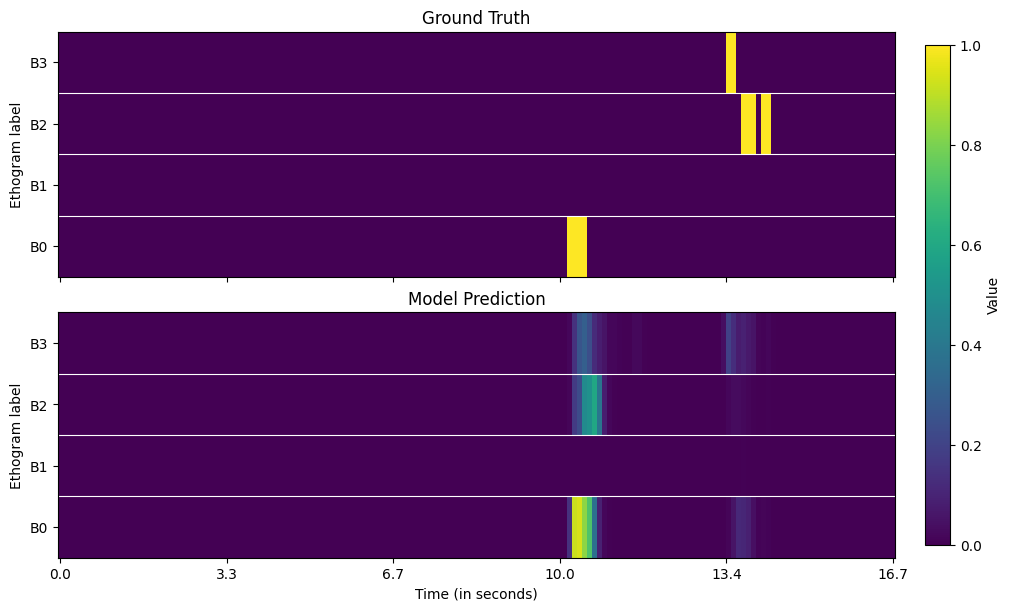


Complete Workflow Finished!

Files created:
  - /work/Jamespeng/Astrocyte/Behavior_and_Neuronal_Data/D21/normalization_stats.json  (dataset statistics)
  - /work/Jamespeng/Astrocyte/Behavior_and_Neuronal_Data/D21/model.pth        (trained model)

Next steps:
  1. Experiment with different hyperparameters
  2. Try hysteresis decoding: use_hysteresis=True
  3. Adjust max_T or batch_size if running into memory issues


In [8]:
# ============================================================================
# 5. VISUALIZE RESULTS
# ============================================================================
print("\n" + "=" * 60)
print("Step 5: Visualizing Results")
print("=" * 60)

from evaluation import plot_ethogram_pair
from models import BehaviorPredictor
from data.preprocessing import load_normalization_stats
import torch.nn as nn

# Load normalization stats
norm_mean, norm_std = load_normalization_stats(normalization_stats_path)

# Load model for inference
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BehaviorPredictor(num_labels=num_labels, norm_mean=norm_mean, norm_std=norm_std).to(device)
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

# Get a test sample
with torch.no_grad():
    for batch in test_loader:
        xb, yb, lengths, stim_type, stim_loc, stim_onset, stim_offset = batch[:7]
        xb = xb.to(device)
        
        # Forward pass
        logits = model(xb, stim_type.to(device), stim_loc.to(device), 
                      stim_onset.to(device), stim_offset.to(device), lengths.to(device))
        preds = torch.sigmoid(logits)
        
        # Get first sample in batch
        L = int(lengths[0].item())
        gt = yb[0, :L, :]       # (T, C)
        pred = preds[0, :L, :]  # (T, C)
        
        # Plot
        behavior_labels = [f'B{i}' for i in range(num_labels)]
        fig, axes = plot_ethogram_pair(
            gt, pred,
            ethogram_labels=behavior_labels,
            fps=10,
            titles=('Ground Truth', 'Model Prediction'),
            show=True
        )
        
        break  # Just plot first sample

print("\n" + "=" * 60)
print("Complete Workflow Finished!")
print("=" * 60)
print("\nFiles created:")
print(f"  - {normalization_stats_path}  (dataset statistics)")
print(f"  - {model_save_path}        (trained model)")
print("\nNext steps:")
print("  1. Experiment with different hyperparameters")
print("  2. Try hysteresis decoding: use_hysteresis=True")
print("  3. Adjust max_T or batch_size if running into memory issues")